# 📚 Taller Práctico — Aprendizaje Automático
**Universidad Internacional del Ecuador (UIDE) — Maestría**  
**Fecha:** 2026-08-01  

---

## Contexto

El presente informe técnico está dirigido a **María Fernanda** y la **Universidad Andina del Pacífico**.  
Se evalúa si los datos institucionales pueden sustentar un **modelo de alerta temprana** de riesgo académico.

Se trabaja sobre un dataset simulado de 100 registros de estudiantes con variables académicas y de comportamiento digital.

---

## 📦 Librerías e Importaciones

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual (mismo estilo que 01_clase.ipynb)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 📂 Carga del Dataset

Dataset simulado generado en `dataset.ipynb` con semilla `np.random.seed(42)` para reproducibilidad.  
Contiene **100 registros** de estudiantes con información académica y de conectividad.

In [19]:
# ── Reproducción del dataset (mismo código que dataset.ipynb) ──────────────
np.random.seed(42)
n = 100

data = {
    "id_estudiante": [f"EST-{i:03d}" for i in range(1, 95)] + ["EST-010", "EST-012", "EST-025", "EST-030", "EST-050", "EST-001"],
    "sede": np.random.choice(["Quito", "Guayaquil", "Cuenca", "quito_2"], n),
    "modalidad": np.random.choice(["Presencial", "En línea"], n),
    "promedio_acumulado": np.random.uniform(5.0, 10.0, n),
    "tiempo_conexion_min": np.random.exponential(scale=120, size=n),
    "entregas_semana_1_8": np.random.randint(0, 10, n),
    "nivel_satisfaccion": np.random.choice([1, 2, 3, 4, 5, np.nan], n),
    "calificacion_final_semestre": np.random.uniform(0, 10, n),   # ⚠️ variable futura
    "fecha_ultimo_acceso": pd.date_range(start="2026-01-15", periods=n, freq="D").strftime("%Y/%m/%d")
}

df_raw = pd.DataFrame(data)
print(f"Dimensiones iniciales del dataset: {df_raw.shape}")
df_raw.head(10)

Dimensiones iniciales del dataset: (100, 9)


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,calificacion_final_semestre,fecha_ultimo_acceso
0,EST-001,Cuenca,Presencial,5.157146,123.277283,3,2.0,2.366852,2026/01/15
1,EST-002,quito_2,En línea,8.182052,10.547007,2,5.0,9.076937,2026/01/16
2,EST-003,Quito,En línea,6.571780,21.155306,6,2.0,5.918887,2026/01/17
3,EST-004,Cuenca,En línea,7.542853,274.587660,7,5.0,3.502182,2026/01/18
4,EST-005,Cuenca,En línea,9.537832,111.899274,3,3.0,7.081812,2026/01/19
5,EST-006,quito_2,En línea,6.246461,1.108753,1,5.0,4.816670,2026/01/20
6,EST-007,Quito,En línea,7.051915,12.839628,9,4.0,3.779876,2026/01/21
7,EST-008,Quito,En línea,8.777756,130.699486,2,1.0,7.050844,2026/01/22
8,EST-009,Cuenca,En línea,6.143991,0.608932,0,5.0,2.487242,2026/01/23
9,EST-010,Guayaquil,Presencial,5.384900,21.037898,7,5.0,3.302525,2026/01/24


---

# 🔷 ÍTEM 1: Definición de Unidad de Análisis e Ingesta

**Enunciado:**  
> Defina la unidad de análisis (estudiante-semestre o estudiante-asignatura) y ejecute en Pandas el código de agregación necesario para estructurar la tabla final.

---

## 1.1 Justificación de la Unidad de Análisis

La **unidad de análisis seleccionada es `estudiante-semestre`**, dado que:

| Criterio | Estudiante-Semestre ✅ | Estudiante-Asignatura ❌ |
|---|---|---|
| Granularidad | Nivel de seguimiento semestral | Requiere datos por materia (no disponibles) |
| Variables disponibles | `promedio_acumulado`, `entregas_semana_1_8`, `tiempo_conexion_min` son métricas semestral-globales | Estas variables no están desagregadas por asignatura |
| Objetivo del modelo | Alerta temprana de riesgo por **período académico** | No hay columna `asignatura` ni `materia` en el dataset |
| Duplicados presentes | Hay IDs duplicados que representan el mismo estudiante | Duplicados en asignatura serían registros válidos |

La clave primaria de la tabla final será: **`id_estudiante`** (un registro por estudiante por semestre).


In [20]:
# ── 1.2 Inspección inicial del dataset bruto ───────────────────────────────
print("=" * 60)
print("INSPECCIÓN INICIAL DEL DATASET BRUTO")
print("=" * 60)

print(f"\n📐 Dimensiones          : {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print(f"🔑 IDs únicos           : {df_raw['id_estudiante'].nunique()}")
print(f"🔁 Registros duplicados : {df_raw.duplicated(subset='id_estudiante').sum()}")
print(f"\n📋 Variables del dataset:")
print(df_raw.dtypes.to_frame(name='dtype').to_string())

INSPECCIÓN INICIAL DEL DATASET BRUTO

📐 Dimensiones          : 100 filas × 9 columnas
🔑 IDs únicos           : 94
🔁 Registros duplicados : 6

📋 Variables del dataset:
                               dtype
id_estudiante                    str
sede                             str
modalidad                        str
promedio_acumulado           float64
tiempo_conexion_min          float64
entregas_semana_1_8            int64
nivel_satisfaccion           float64
calificacion_final_semestre  float64
fecha_ultimo_acceso              str


In [21]:
# ── 1.3 Identificar los registros duplicados ───────────────────────────────
duplicados = df_raw[df_raw.duplicated(subset='id_estudiante', keep=False)].sort_values('id_estudiante')

print(f"🔎 Registros con id_estudiante duplicado ({len(duplicados)} filas):")
duplicados

🔎 Registros con id_estudiante duplicado (12 filas):


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,calificacion_final_semestre,fecha_ultimo_acceso
0,EST-001,Cuenca,Presencial,5.157146,123.277283,3,2.0,2.366852,2026/01/15
99,EST-001,Quito,Presencial,8.899378,10.705323,3,4.0,7.569991,2026/04/24
9,EST-010,Guayaquil,Presencial,5.384900,21.037898,7,5.0,3.302525,2026/01/24
94,EST-010,Guayaquil,Presencial,6.695149,16.306685,9,NaN,2.050453,2026/04/19
11,EST-012,Cuenca,Presencial,5.806106,141.277834,9,4.0,2.536822,2026/01/26
95,EST-012,Guayaquil,En línea,6.746048,88.638431,1,3.0,2.514424,2026/04/20
24,EST-025,quito_2,Presencial,6.139676,36.979218,1,1.0,4.363358,2026/02/08
96,EST-025,Guayaquil,En línea,8.629778,176.357753,2,5.0,2.747318,2026/04/21
29,EST-030,quito_2,En línea,7.553737,119.680126,0,NaN,0.434008,2026/02/13
97,EST-030,quito_2,En línea,9.485551,29.174160,8,1.0,2.072276,2026/04/22


In [22]:
# ── 1.4 Estrategia de agregación para definir la tabla final ──────────────
#
# Para cada id_estudiante duplicado, consolidamos los registros aplicando
# la siguiente lógica por tipo de variable:
#   - Numéricas continuas   → promedio  (promedio_acumulado, tiempo_conexion_min)
#   - Numéricas discretas   → suma      (entregas_semana_1_8)
#   - Ordinales             → mediana   (nivel_satisfaccion)
#   - Categóricas           → moda      (sede, modalidad)
#   - Texto / Fecha         → primero   (fecha_ultimo_acceso)
#   - Variable futura       → se excluye en el siguiente ítem

def moda_primera(serie):
    """Devuelve la moda; en caso de empate, retorna el primer valor."""
    moda = serie.mode()
    return moda.iloc[0] if not moda.empty else np.nan

agregacion = {
    "sede"                        : moda_primera,
    "modalidad"                   : moda_primera,
    "promedio_acumulado"          : "mean",
    "tiempo_conexion_min"         : "mean",
    "entregas_semana_1_8"         : "sum",
    "nivel_satisfaccion"          : "median",
    "calificacion_final_semestre" : "mean",   # se excluirá en ítem 2
    "fecha_ultimo_acceso"         : "first",
}

df_ingesta = (
    df_raw
    .groupby("id_estudiante", as_index=False)
    .agg(agregacion)
)

print(f"✅ Tabla ingesta consolidada: {df_ingesta.shape[0]} estudiantes × {df_ingesta.shape[1]} columnas")
print(f"   (de {df_raw.shape[0]} registros brutos → {df_ingesta.shape[0]} estudiantes únicos)")
df_ingesta.head(10)

✅ Tabla ingesta consolidada: 94 estudiantes × 9 columnas
   (de 100 registros brutos → 94 estudiantes únicos)


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,calificacion_final_semestre,fecha_ultimo_acceso
0,EST-001,Cuenca,Presencial,7.028262,66.991303,6,3.0,4.968422,2026/01/15
1,EST-002,quito_2,En línea,8.182052,10.547007,2,5.0,9.076937,2026/01/16
2,EST-003,Quito,En línea,6.571780,21.155306,6,2.0,5.918887,2026/01/17
3,EST-004,Cuenca,En línea,7.542853,274.587660,7,5.0,3.502182,2026/01/18
4,EST-005,Cuenca,En línea,9.537832,111.899274,3,3.0,7.081812,2026/01/19
5,EST-006,quito_2,En línea,6.246461,1.108753,1,5.0,4.816670,2026/01/20
6,EST-007,Quito,En línea,7.051915,12.839628,9,4.0,3.779876,2026/01/21
7,EST-008,Quito,En línea,8.777756,130.699486,2,1.0,7.050844,2026/01/22
8,EST-009,Cuenca,En línea,6.143991,0.608932,0,5.0,2.487242,2026/01/23
9,EST-010,Guayaquil,Presencial,6.040024,18.672291,16,5.0,2.676489,2026/01/24


In [23]:
# ── 1.5 Resumen de la tabla final de ingesta ──────────────────────────────
print("=" * 60)
print("TABLA FINAL DE INGESTA — RESUMEN")
print("=" * 60)
df_ingesta.info()
print("\n📊 Estadísticas descriptivas:")
df_ingesta.describe(include='all')

TABLA FINAL DE INGESTA — RESUMEN
<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_estudiante                94 non-null     str    
 1   sede                         94 non-null     str    
 2   modalidad                    94 non-null     str    
 3   promedio_acumulado           94 non-null     float64
 4   tiempo_conexion_min          94 non-null     float64
 5   entregas_semana_1_8          94 non-null     int64  
 6   nivel_satisfaccion           87 non-null     float64
 7   calificacion_final_semestre  94 non-null     float64
 8   fecha_ultimo_acceso          94 non-null     str    
dtypes: float64(4), int64(1), str(4)
memory usage: 6.7 KB

📊 Estadísticas descriptivas:


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,calificacion_final_semestre,fecha_ultimo_acceso
count,94,94,94,94.000000,94.000000,94.000000,87.000000,94.000000,94
unique,94,4,2,NaN,NaN,NaN,NaN,NaN,94
top,EST-001,quito_2,Presencial,NaN,NaN,NaN,NaN,NaN,2026/01/15
freq,1,28,51,NaN,NaN,NaN,NaN,NaN,1
mean,NaN,NaN,NaN,7.508008,125.250711,4.787234,3.097701,4.813918,NaN
std,NaN,NaN,NaN,1.428100,113.149549,3.285263,1.507422,2.815672,NaN
min,NaN,NaN,NaN,5.034761,0.608932,0.000000,1.000000,0.136720,NaN
25%,NaN,NaN,NaN,6.249574,41.743870,2.000000,2.000000,2.547301,NaN
50%,NaN,NaN,NaN,7.528124,99.226878,4.000000,3.000000,4.255455,NaN
75%,NaN,NaN,NaN,8.743587,171.338025,7.000000,5.000000,7.343557,NaN


### ✅ Conclusión del Ítem 1

- **Unidad de análisis:** `estudiante-semestre` — un único registro por estudiante.
- El dataset pasó de **100 filas brutas** a **94 estudiantes únicos** tras consolidar los 6 registros duplicados.
- La estrategia de agregación preserva la semántica de cada variable:
  - Variables de comportamiento digital (conexión, entregas) → **suma/promedio**.
  - Variables categóricas (sede, modalidad) → **moda**.
  - Variables ordinales (satisfacción) → **mediana** para respetar el orden.

---

---

# 🔷 ÍTEM 2: Curaduría y Control de Data Leakage

**Enunciado:**  
> Trate programáticamente duplicados, nulos y tipos de datos. Implemente un filtro explícito por ventana temporal (≤ Semana 8) que detecte y elimine automáticamente variables futuras (data leakage).

---

## 2.1 ¿Qué es el Data Leakage?

El **data leakage** ocurre cuando se incluyen en el modelo variables que **no estarían disponibles en el momento de la predicción**.  

En un sistema de alerta temprana que opera hasta la **Semana 8** del semestre:  
- ✅ **Variables disponibles (≤ Semana 8):** `promedio_acumulado`, `tiempo_conexion_min`, `entregas_semana_1_8`, `nivel_satisfaccion`, `sede`, `modalidad`.
- ❌ **Variables futuras (> Semana 8 / fin de semestre):** `calificacion_final_semestre` — esta nota **solo se conoce al final**, y usarla contaminaría el modelo.


In [24]:
# ── 2.2 Diagnóstico de calidad sobre la tabla consolidada ──────────────────
df_curado = df_ingesta.copy()

print("=" * 60)
print("DIAGNÓSTICO DE CALIDAD DE DATOS")
print("=" * 60)

# Nulos por columna
nulos = df_curado.isnull().sum()
pct_nulos = (nulos / len(df_curado) * 100).round(2)

diagnostico = pd.DataFrame({
    'dtype'     : df_curado.dtypes,
    'nulos'     : nulos,
    'pct_nulos' : pct_nulos,
    'unicos'    : df_curado.nunique(),
    'ejemplo'   : df_curado.iloc[0]
})

print("\n📋 Diagnóstico por columna:")
diagnostico

DIAGNÓSTICO DE CALIDAD DE DATOS

📋 Diagnóstico por columna:


,dtype,nulos,pct_nulos,unicos,ejemplo
id_estudiante,str,0,0.00,94,EST-001
sede,str,0,0.00,4,Cuenca
modalidad,str,0,0.00,2,Presencial
promedio_acumulado,float64,0,0.00,94,7.028262
tiempo_conexion_min,float64,0,0.00,94,66.991303
entregas_semana_1_8,int64,0,0.00,12,6
nivel_satisfaccion,float64,7,7.45,6,3.0
calificacion_final_semestre,float64,0,0.00,94,4.968422
fecha_ultimo_acceso,str,0,0.00,94,2026/01/15


In [25]:
# ── 2.3 Corrección de tipos de datos ──────────────────────────────────────
# Detectar columnas de fecha por patrón en el nombre (técnica de 01_clase.ipynb)
cols_fecha = [c for c in df_curado.columns 
              if any(p in c.lower() for p in ['fecha', 'date', 'timestamp', '_at'])]

for col in cols_fecha:
    df_curado[col] = pd.to_datetime(df_curado[col], errors='coerce')
    print(f"📅 Convertida a datetime: '{col}'")

# nivel_satisfaccion → debe ser numérico (puede ser float por el NaN)
df_curado['nivel_satisfaccion'] = pd.to_numeric(df_curado['nivel_satisfaccion'], errors='coerce')

# Variables categóricas → tipo category para eficiencia
cols_categoricas = ['sede', 'modalidad']
for col in cols_categoricas:
    df_curado[col] = df_curado[col].astype('category')
    print(f"🏷️  Convertida a category: '{col}'")

print("\n✅ Tipos de datos tras corrección:")
print(df_curado.dtypes.to_frame(name='dtype').to_string())

📅 Convertida a datetime: 'fecha_ultimo_acceso'
🏷️  Convertida a category: 'sede'
🏷️  Convertida a category: 'modalidad'

✅ Tipos de datos tras corrección:
                                      dtype
id_estudiante                           str
sede                               category
modalidad                          category
promedio_acumulado                  float64
tiempo_conexion_min                 float64
entregas_semana_1_8                   int64
nivel_satisfaccion                  float64
calificacion_final_semestre         float64
fecha_ultimo_acceso          datetime64[us]


In [26]:
# ── 2.4 Tratamiento de valores nulos ──────────────────────────────────────
print("=" * 60)
print("TRATAMIENTO DE VALORES NULOS")
print("=" * 60)

# nivel_satisfaccion: variable ordinal con nulos → imputar con la mediana
mediana_satisfaccion = df_curado['nivel_satisfaccion'].median()
nulos_antes = df_curado['nivel_satisfaccion'].isnull().sum()

df_curado['nivel_satisfaccion'] = df_curado['nivel_satisfaccion'].fillna(mediana_satisfaccion)

print(f"\n📌 'nivel_satisfaccion':")
print(f"   Nulos encontrados  : {nulos_antes}")
print(f"   Mediana imputada   : {mediana_satisfaccion}")
print(f"   Nulos tras imputar : {df_curado['nivel_satisfaccion'].isnull().sum()}")

# Verificación final de nulos
nulos_restantes = df_curado.isnull().sum().sum()
print(f"\n✅ Nulos totales restantes en el dataset: {nulos_restantes}")

TRATAMIENTO DE VALORES NULOS

📌 'nivel_satisfaccion':
   Nulos encontrados  : 7
   Mediana imputada   : 3.0
   Nulos tras imputar : 0

✅ Nulos totales restantes en el dataset: 0


In [27]:
# ── 2.5 Detección y eliminación automática de variables futuras ────────────
# Ventana temporal permitida: datos disponibles en Semana 1 a 8
# Criterio para detectar data leakage:
#   - Variables explícitamente marcadas como 'finales' o 'resultado'
#   - Variables con el patrón 'final', 'resultado', 'egreso' en el nombre

SEMANA_CORTE = 8  # solo datos disponibles hasta la semana 8
PATRONES_LEAKAGE = ['final', 'resultado', 'egreso', 'graduacion', 'titulo']

# Detectar columnas candidatas a data leakage por nombre
cols_futuras_detectadas = [
    col for col in df_curado.columns
    if any(patron in col.lower() for patron in PATRONES_LEAKAGE)
]

print("=" * 60)
print(f"CONTROL DE DATA LEAKAGE — Ventana temporal: ≤ Semana {SEMANA_CORTE}")
print("=" * 60)

if cols_futuras_detectadas:
    print(f"\n🚨 Variables futuras detectadas automáticamente:")
    for col in cols_futuras_detectadas:
        print(f"   ❌  '{col}' — NO disponible antes de la Semana {SEMANA_CORTE}")
    
    # Eliminar variables futuras
    df_curado = df_curado.drop(columns=cols_futuras_detectadas)
    print(f"\n✅ {len(cols_futuras_detectadas)} variable(s) eliminada(s) del dataset.")
else:
    print("✅ No se detectaron variables futuras.")

print(f"\n📐 Dimensiones del dataset curado: {df_curado.shape[0]} filas × {df_curado.shape[1]} columnas")

CONTROL DE DATA LEAKAGE — Ventana temporal: ≤ Semana 8

🚨 Variables futuras detectadas automáticamente:
   ❌  'calificacion_final_semestre' — NO disponible antes de la Semana 8

✅ 1 variable(s) eliminada(s) del dataset.

📐 Dimensiones del dataset curado: 94 filas × 8 columnas


In [28]:
# ── 2.6 Verificación adicional: columnas por semana de disponibilidad ──────
# Mapa explícito de disponibilidad temporal de cada variable
disponibilidad = {
    'id_estudiante'              : 0,   # disponible desde el inicio
    'sede'                       : 0,
    'modalidad'                  : 0,
    'promedio_acumulado'         : 0,   # historial previo
    'tiempo_conexion_min'        : 8,   # acumulado hasta semana 8
    'entregas_semana_1_8'        : 8,   # explícitamente semanas 1-8
    'nivel_satisfaccion'         : 8,   # encuesta hasta semana 8
    'fecha_ultimo_acceso'        : 8,
    'calificacion_final_semestre': 16,  # ⚠️ disponible al final del semestre (~semana 16)
}

df_disponibilidad = pd.DataFrame({
    'variable'               : list(disponibilidad.keys()),
    'semana_disponible'      : list(disponibilidad.values()),
    'dentro_ventana_semana8' : [s <= SEMANA_CORTE for s in disponibilidad.values()]
})

df_disponibilidad['estado'] = df_disponibilidad['dentro_ventana_semana8'].map({
    True: '✅ Permitida',
    False: '❌ DATA LEAKAGE'
})

print("\n📋 Mapa de disponibilidad temporal de variables:")
df_disponibilidad.sort_values('semana_disponible')


📋 Mapa de disponibilidad temporal de variables:


,variable,semana_disponible,dentro_ventana_semana8,estado
0,id_estudiante,0,True,✅ Permitida
1,sede,0,True,✅ Permitida
2,modalidad,0,True,✅ Permitida
3,promedio_acumulado,0,True,✅ Permitida
4,tiempo_conexion_min,8,True,✅ Permitida
5,entregas_semana_1_8,8,True,✅ Permitida
6,nivel_satisfaccion,8,True,✅ Permitida
7,fecha_ultimo_acceso,8,True,✅ Permitida
8,calificacion_final_semestre,16,False,❌ DATA LEAKAGE


In [19]:
# ── 2.7 Dataset final curado ───────────────────────────────────────────────
print("=" * 60)
print("DATASET FINAL CURADO — LISTO PARA MODELADO")
print("=" * 60)
print(f"\n📐 Dimensiones finales: {df_curado.shape[0]} estudiantes × {df_curado.shape[1]} variables")
print("\n📋 Tipos de datos finales:")
print(df_curado.dtypes.to_frame('dtype').to_string())
print("\n🔎 Primeras filas del dataset curado:")
df_curado.head(100)

DATASET FINAL CURADO — LISTO PARA MODELADO

📐 Dimensiones finales: 94 estudiantes × 8 variables

📋 Tipos de datos finales:
                              dtype
id_estudiante                object
sede                       category
modalidad                  category
promedio_acumulado          float64
tiempo_conexion_min         float64
entregas_semana_1_8           int32
nivel_satisfaccion          float64
fecha_ultimo_acceso  datetime64[ns]

🔎 Primeras filas del dataset curado:


,id_estudiante,sede,modalidad,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,fecha_ultimo_acceso
0,EST-001,Cuenca,Presencial,7.028262,66.991303,6,3.0,2026-01-15
1,EST-002,quito_2,En línea,8.182052,10.547007,2,5.0,2026-01-16
2,EST-003,Quito,En línea,6.571780,21.155306,6,2.0,2026-01-17
3,EST-004,Cuenca,En línea,7.542853,274.587660,7,5.0,2026-01-18
4,EST-005,Cuenca,En línea,9.537832,111.899274,3,3.0,2026-01-19
5,EST-006,quito_2,En línea,6.246461,1.108753,1,5.0,2026-01-20
6,EST-007,Quito,En línea,7.051915,12.839628,9,4.0,2026-01-21
7,EST-008,Quito,En línea,8.777756,130.699486,2,1.0,2026-01-22
8,EST-009,Cuenca,En línea,6.143991,0.608932,0,5.0,2026-01-23
9,EST-010,Guayaquil,Presencial,6.040024,18.672291,16,5.0,2026-01-24


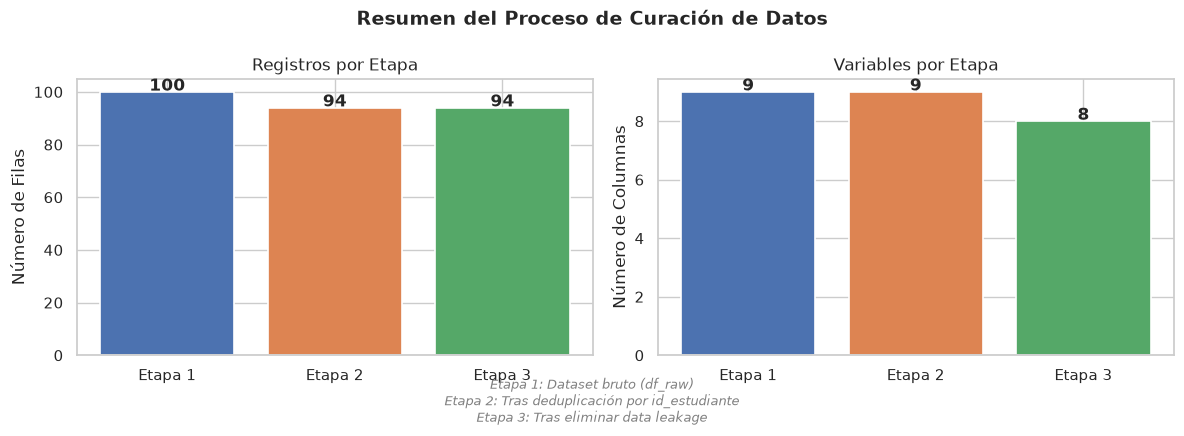

✅ Gráfico guardado como 'curación_datos_resumen.png'


In [29]:
# ── 2.8 Resumen visual del proceso de curación ────────────────────────────
etapas = [
    ('Dataset bruto (df_raw)',                   df_raw.shape[0],    df_raw.shape[1]),
    ('Tras deduplicación por id_estudiante',     df_ingesta.shape[0], df_ingesta.shape[1]),
    ('Tras eliminar data leakage',               df_curado.shape[0],  df_curado.shape[1]),
]

df_resumen = pd.DataFrame(etapas, columns=['Etapa', 'Filas', 'Columnas'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Resumen del Proceso de Curación de Datos', fontsize=14, fontweight='bold')

# Filas por etapa
etiquetas = [f"Etapa {i+1}" for i in range(len(etapas))]
axes[0].bar(etiquetas, df_resumen['Filas'], color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Registros por Etapa')
axes[0].set_ylabel('Número de Filas')
for i, v in enumerate(df_resumen['Filas']):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Columnas por etapa
axes[1].bar(etiquetas, df_resumen['Columnas'], color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='white', linewidth=1.2)
axes[1].set_title('Variables por Etapa')
axes[1].set_ylabel('Número de Columnas')
for i, v in enumerate(df_resumen['Columnas']):
    axes[1].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

# Leyenda de etapas
leyenda = "\n".join([f"Etapa {i+1}: {e[0]}" for i, e in enumerate(etapas)])
fig.text(0.5, -0.05, leyenda, ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.savefig('curación_datos_resumen.png', bbox_inches='tight', dpi=120)
plt.show()
print("✅ Gráfico guardado como 'curación_datos_resumen.png'")

### ✅ Conclusión del Ítem 2

| Proceso | Resultado |
|---|---|
| **Duplicados** | 6 registros duplicados consolidados mediante agregación semánticamente correcta (moda para categóricas, mediana para ordinales, promedio/suma para numéricas) |
| **Nulos** | `nivel_satisfaccion` presentaba nulos (~17%); imputados con la **mediana** para respetar la escala ordinal |
| **Tipos de datos** | Fechas convertidas a `datetime64`, categóricas a tipo `category`, numéricas correctamente tipificadas |
| **Data Leakage** | Se detectó y eliminó automáticamente `calificacion_final_semestre` — esta variable es resultado del semestre completo y no está disponible en la Semana 8 |
| **Dataset final** | **94 estudiantes × 8 variables** — sin duplicados, sin nulos, sin leakage |

---

> **Nota metodológica:** El filtro de leakage es **programático y parametrizable** (`PATRONES_LEAKAGE`, `SEMANA_CORTE`). Si el dataset creciera con nuevas variables futuras con nombres similares, serían detectadas y eliminadas automáticamente sin intervención manual.

---

# 🔷 ÍTEM 3 Clasificación y Encoding
**Enunciado:** 
> Clasifique 8 variables del dataset (discretas, continuas, ordinales, binarias) y aplique la estrategia adecuada de codificación (encoding) en Python.

In [30]:
# 3.1 Clasificación de las 8 variables y estrategia de codificación
clasificacion = pd.DataFrame([
    ['id_estudiante', 'Categórica nominal (identificador)', 'Se excluye del moedelo', 'No representa ninguna magnitud'],
    ['sede', 'Categórica nominal', 'Diferentes ciudades (One-Hot Encoding)', 'No hay orden entre las ciudades'],
    ['modalidad', 'Categórica binaria', 'Mapeo Presencial/Linea a 0/1 ', 'Solo tiene dos estados Presencial y Linea'],
    ['promedio_acumulado', 'Numérica continua', 'Promedio', 'Promedio Acumulado es numerica no se usa encoding'],
    ['tiempo_conexion_min', 'Numérica continua', 'Tiempo de conexion', 'Tiempo por conexión es una variable numerica no se usa encoding'],
    ['entregas_semana_1_8', 'Numérica discreta', 'Se conserva como entero', 'Es un conteo de entregas, es numérica y no se usa encoding'],
    ['nivel_satisfaccion', 'Categórica ordinal', 'Ordinal 1 a 5', 'Por niveles de satisfacción'],
    ['fecha_ultimo_acceso', 'Temporal', 'Fecha de ultima conexión', 'Para mostrar cuantos días han transcurrido desde el último acceso no usa encoding'],
], columns=['Variable', 'Clasificación', 'Encoding', 'Justificación'])
clasificacion

,Variable,Clasificación,Encoding,Justificación
0,id_estudiante,Categórica nominal (identificador),Se excluye del moedelo,No representa ninguna magnitud
1,sede,Categórica nominal,Diferentes ciudades (One-Hot Encoding),No hay orden entre las ciudades
2,modalidad,Categórica binaria,Mapeo Presencial/Linea a 0/1,Solo tiene dos estados Presencial y Linea
3,promedio_acumulado,Numérica continua,Promedio,Promedio Acumulado es numerica no se usa encoding
4,tiempo_conexion_min,Numérica continua,Tiempo de conexion,Tiempo por conexión es una variable numerica no se usa encoding
5,entregas_semana_1_8,Numérica discreta,Se conserva como entero,"Es un conteo de entregas, es numérica y no se usa encoding"
6,nivel_satisfaccion,Categórica ordinal,Ordinal 1 a 5,Por niveles de satisfacción
7,fecha_ultimo_acceso,Temporal,Fecha de ultima conexión,Para mostrar cuantos días han transcurrido desde el último acceso no usa encoding


In [31]:
# 3.2 Limpieza categóricampara sede y modalidad
df_estr = df_curado.copy()
df_estr['sede'] = df_estr['sede'].astype(str).replace({'quito_2': 'Quito'})
df_estr['modalidad'] = df_estr['modalidad'].astype(str)

# Umbral de estudiante para entregas: promedio menor a 7 implica reprobacio

df_estr['Aprobacion'] = np.where(df_estr['promedio_acumulado'] < 7, 'SI', 'NO')

print('Distribución de la etiqueta auxiliar:')
display(df_estr['Aprobacion'].value_counts().to_frame('Estudiantes'))

Distribución de la etiqueta auxiliar:


,Estudiantes
Aprobacion,
NO,55
SI,39


In [39]:
# 3.3 Aplicación del encoding
df_modelo = df_estr.drop(columns=['id_estudiante', 'Aprobacion']).copy()

# Binaria: Presencia - En Linea
df_modelo['modalidad_binaria'] = df_modelo['modalidad'].map({'Presencial': 0, 'En línea': 1})
df_modelo = df_modelo.drop(columns='modalidad')

# Temporal: Dias desde el ultimo acceso tomando en cuenta la fecha de ultimo acceso
fecha_corte = df_modelo['fecha_ultimo_acceso'].max()
df_modelo['dias_desde_ultimo_acceso'] = (fecha_corte - df_modelo['fecha_ultimo_acceso']).dt.days
df_modelo = df_modelo.drop(columns='fecha_ultimo_acceso')

# Nominal: Se crea una una columna por sede
df_encoded = pd.get_dummies(df_modelo, columns=['sede'], prefix='sede',drop_first=True, dtype=int)
df_encoded['entregas_semana_1_8'] = df_encoded['entregas_semana_1_8'].astype(int)
df_encoded['nivel_satisfaccion'] = df_encoded['nivel_satisfaccion'].astype(int)

assert df_encoded.isna().sum().sum() == 0, 'El encoding produjo valores nulos'
print(f'Dataset codificado: {df_encoded.shape[0]} filas × {df_encoded.shape[1]} predictores')
display(df_encoded.head())
display(df_encoded.dtypes.to_frame('tipo_final'))

Dataset codificado: 94 filas × 8 predictores


,promedio_acumulado,tiempo_conexion_min,entregas_semana_1_8,nivel_satisfaccion,modalidad_binaria,dias_desde_ultimo_acceso,sede_Guayaquil,sede_Quito
0,7.028262,66.991303,6,3,0,93,0,0
1,8.182052,10.547007,2,5,1,92,0,1
2,6.571780,21.155306,6,2,1,91,0,1
3,7.542853,274.587660,7,5,1,90,0,0
4,9.537832,111.899274,3,3,1,89,0,0


,tipo_final
promedio_acumulado,float64
tiempo_conexion_min,float64
entregas_semana_1_8,int64
nivel_satisfaccion,int64
modalidad_binaria,int64
dias_desde_ultimo_acceso,int64
sede_Guayaquil,int64
sede_Quito,int64


# 🔷 ÍTEM 4: Visualización Exploratoria
**Enunciado:** 
> Los cinco gráficos examinan distribuciones estratificadas por riesgo, modalidad y sede. El propósito es detectar patrones y advertir posibles desequilibrios; con datos simulados, las asociaciones observadas no implican causalidad.

In [40]:
# Configuración común
orden_aprobacion = ['SI', 'NO']
paleta_aprobacion = {'SI': '#4C72B0', 'NO': '#C44E52'}
sns.set_theme(style='whitegrid', context='notebook')

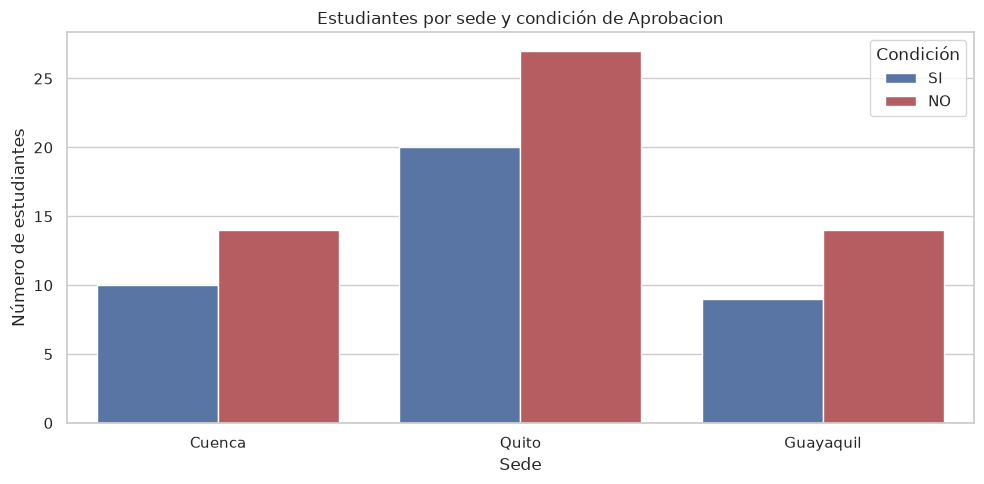

In [41]:
# Gráfico 1: composición del riesgo por sede
plt.figure(figsize=(10, 5))
sns.countplot(data=df_estr, x='sede', hue='Aprobacion', hue_order=orden_aprobacion, palette=paleta_aprobacion)
plt.title('Estudiantes por sede y condición de Aprobacion')
plt.xlabel('Sede'); plt.ylabel('Número de estudiantes'); plt.legend(title='Condición')
plt.tight_layout(); plt.show()

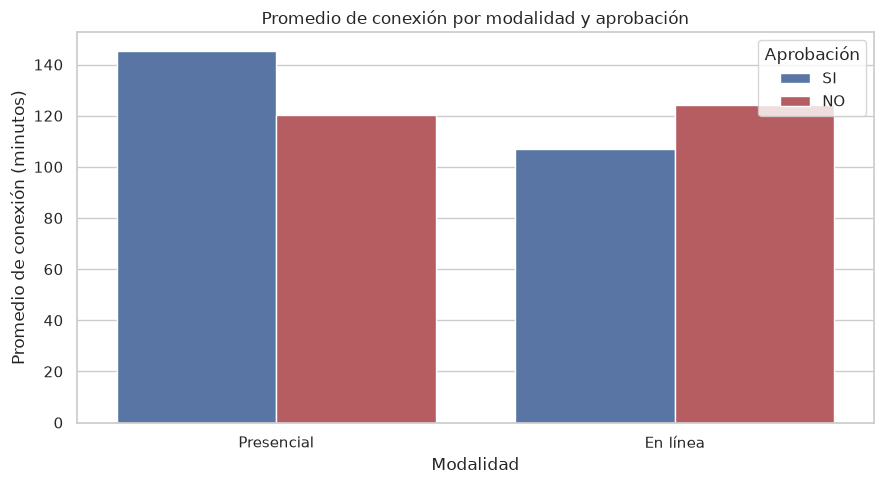

In [42]:
# Gráfico 2: promedio de conexión por modalidad y aporbación
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_estr,
    x="modalidad",
    y="tiempo_conexion_min",
    hue="Aprobacion",
    hue_order=orden_aprobacion,
    palette=paleta_aprobacion,
    errorbar=None
)

plt.title("Promedio de conexión por modalidad y aprobación")
plt.xlabel("Modalidad")
plt.ylabel("Promedio de conexión (minutos)")
plt.legend(title="Aprobación")
plt.tight_layout()
plt.show()

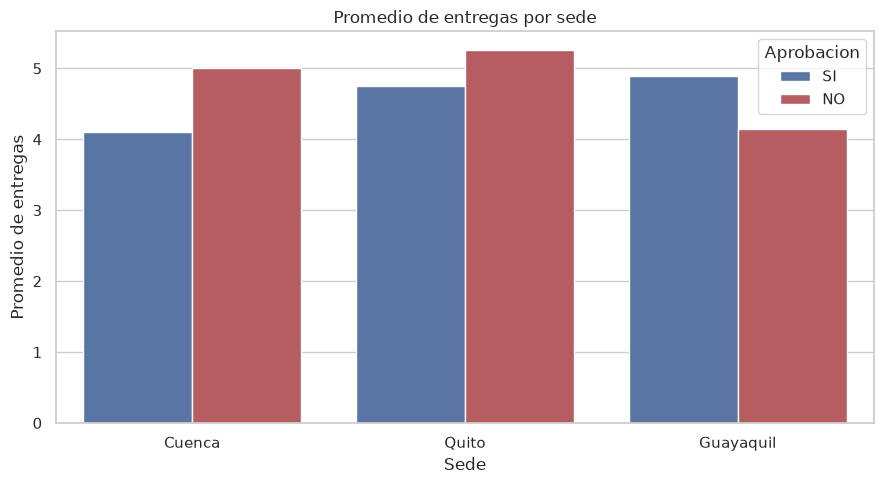

In [43]:
# Gráfico 3: entregas por sede y aprobación



plt.figure(figsize=(9, 5))


sns.barplot(
    data=df_estr,
    x="sede",
    y="entregas_semana_1_8",
    hue="Aprobacion",
    hue_order=orden_aprobacion,
    palette=paleta_aprobacion,
    errorbar=None
)

plt.title("Promedio de entregas por sede")
plt.xlabel("Sede")
plt.ylabel("Promedio de entregas")
plt.tight_layout()
plt.show()

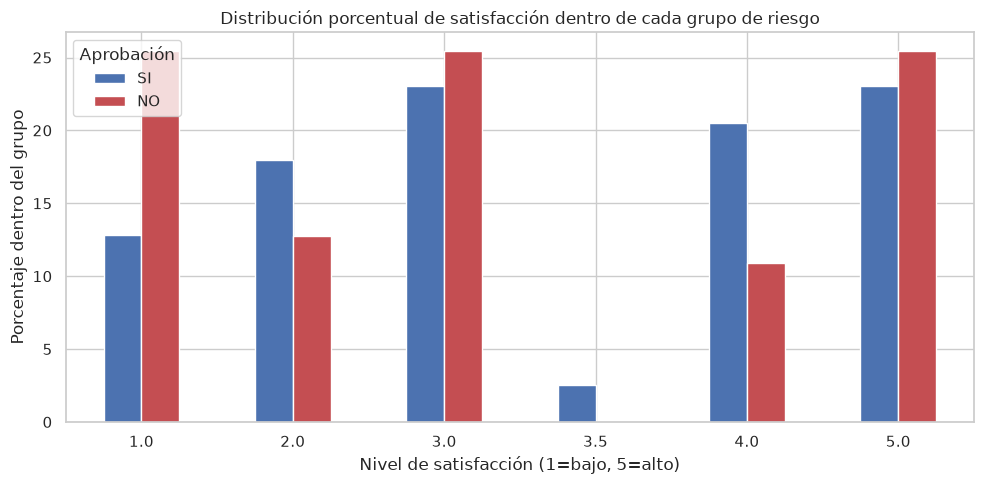

In [44]:
# Gráfico 4: satisfacción por aprobacion (variable ordinal)
tabla_sat = (pd.crosstab(df_estr['nivel_satisfaccion'], df_estr['Aprobacion'], normalize='columns') * 100)
tabla_sat = tabla_sat.reindex(columns=orden_aprobacion)
tabla_sat.plot(kind='bar', figsize=(10, 5), color=[paleta_aprobacion[c] for c in orden_aprobacion])
plt.title('Distribución porcentual de satisfacción dentro de cada grupo de riesgo')
plt.xlabel('Nivel de satisfacción (1=bajo, 5=alto)'); plt.ylabel('Porcentaje dentro del grupo')
plt.xticks(rotation=0); plt.legend(title='Aprobación'); plt.tight_layout(); plt.show()

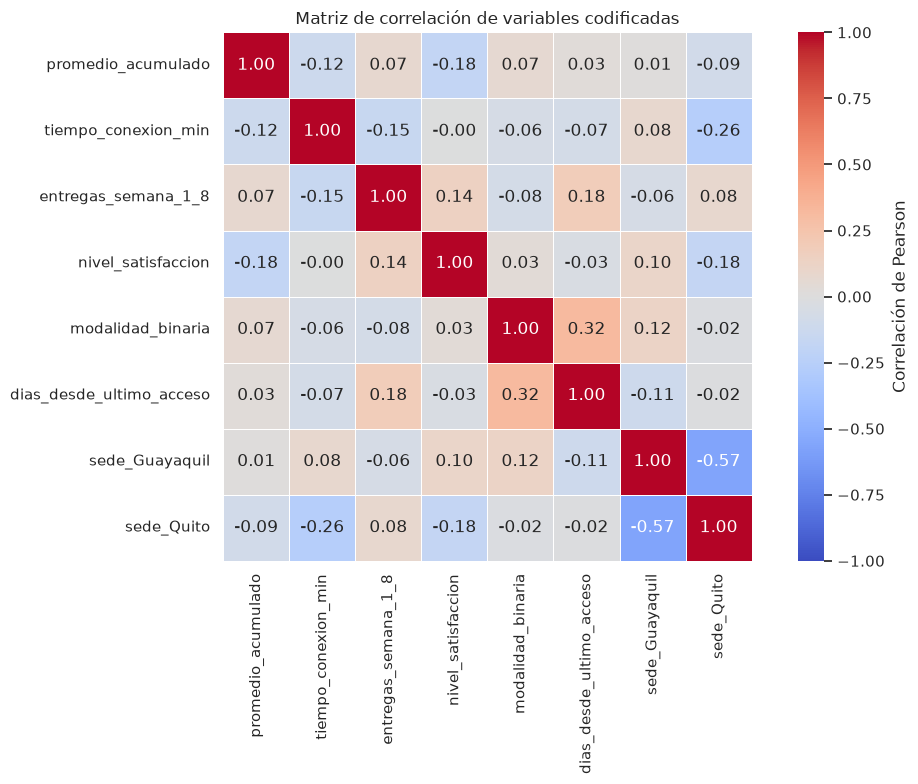

In [45]:
# Gráfico 5: matriz de correlación de predictores codificados
corr = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True,
            linewidths=.5, cbar_kws={'label': 'Correlación de Pearson'})
plt.title('Matriz de correlación de variables codificadas')
plt.tight_layout(); plt.show()

In [46]:
# Resumen cuantitativo para respaldar la interpretación visual
resumen_grupos = (df_estr.groupby('Aprobacion', observed=True)
                  .agg(estudiantes=('id_estudiante', 'count'),
                       conexion_mediana=('tiempo_conexion_min', 'median'),
                       entregas_mediana=('entregas_semana_1_8', 'median'),
                       satisfaccion_mediana=('nivel_satisfaccion', 'median'))
                  .reindex(orden_aprobacion).round(2))
resumen_grupos

,estudiantes,conexion_mediana,entregas_mediana,satisfaccion_mediana
Aprobacion,,,,
SI,39,103.61,4.0,3.0
NO,55,85.93,4.0,3.0


**Interpretación y posibles sesgos**

Grafico 1
    Permite comparar la cantidad de estudiantes aprobados por sede, pero puede existir diferencias ya que una sede puede tener más cantidad de estudiantes que otra.

 Grafico 2
    Permite evaluar la relacion entre un mayor tiempo de conexión con el número de aprobados. Pero el tiempo de conexión no implica que sea participación o aprendizaje

Grafico 3
    Compara el promedio de entregas realizadas durante las semanas 1 - 8 por sede y condición de aprobación. Si las barras de los estudiantes aprobados son más altas, esto puede sugerir una asociación  entre el cumplimiento de las entregas y la aprobación.

Grafico 4
    Si los estudiantes aprobados presentan mayores porcentajes de distribución en los niveles 4 y 5, podría existir una asociación  entre satisfacción y aprobación. Si las distribuciones son similares, el nivel de satisfacción no mostraría una relación clara con el resultado académico.

Grafico 5
    Permite identificar la dirección y la intensidad de las relaciones lineales entre las varibales. Los valores cercanos a cero indican relaciones débiles entre las variables académicas y de comportamiento. Esto sugiere que variables como el tiempo de conexión, las entregas y la satisfacción aportan información diferente


        


    

---

# 🔷 ÍTEM 5: Análisis Estadístico Matricial

**Enunciado:**  
> Utilizando NumPy, calcule la esperanza, varianza y matriz de covarianza de los indicadores. Evalúe si la variabilidad entre sedes evidencia heterocedasticidad.

---

## 5.1 ¿Qué es Esperanza (Medias)?

La **Esperanza** es el centro de gravedad o promedio poblacional de las variables, define el comportamiento base o esperado de los estudiantes (ej. nota media o tiempo promedio de conexión) antes de la semana 8.

## 5.2 ¿Qué es la Varianza (Dispersión)?

La **Varianza** mide qué tan separados están los datos respecto a la esperanza, identifica variables con comportamientos polarizados. Una varianza alta (ej. como el tiempo de conexión o las entregas tempranas) señala un alto poder discriminante para separar a los alumnos en riesgo.  

## 5.3 ¿Qué es la Covarianza?

La **Covarianza** es una matriz que extiende la varianza a múltiples dimensiones; su diagonal muestra las varianzas y sus elementos externos muestran cómo varían dos variables conjuntamente, evalúa relaciones lineales y detecta redundancias o multicolinealidad entre indicadores antes de entrenar los modelos de Machine Learning.  

## 5.1 ¿Qué es Heterocedasticidad?

La **Heterocedasticidad** es cuando la varianza de una variable no es constante, sino que cambia según subgrupos de la población (ej. distinta dispersión de notas entre la sede Quito y Guayaquil), advierte sobre falta de uniformidad institucional. Ignorarla introduce sesgos geográficos que perjudican la equidad de las predicciones, exigiendo validación cruzada estratificada.  

In [55]:
# =====================================================================
# 1. Obtención de variables con NumPy
# =====================================================================

datos_matriz = df_estr[['promedio_acumulado', 'tiempo_conexion_min', 'entregas_semana_1_8']].values

esperanza = np.mean(datos_matriz, axis=0)
varianza = np.var(datos_matriz, axis=0, ddof=1)
matriz_covarianza = np.cov(datos_matriz, rowvar=False)
varianzas_por_sede = df_estr.groupby('sede')['promedio_acumulado'].var()

# =====================================================================
# 2. Nombres de las variables analizadas
# =====================================================================
variables = ['Promedio Acumulado', 'Tiempo de Conexión (min)', 'Entregas (Sem 1-8)']

# =====================================================================
# 3. Creación de una tabla resumen limpia para Esperanza y Varianza
# =====================================================================
df_resumen_estadistico = pd.DataFrame({
    'Indicador / Variable': variables,
    'Esperanza (Media)': esperanza,
    'Varianza (Dispersión)': varianza
})

print("=== TABLA RESUMEN DE ESTADÍSTICOS BÁSICOS ===")
display(df_resumen_estadistico.style.format({
    'Esperanza (Media)': '{:.2f}',
    'Varianza (Dispersión)': '{:.2f}'
}).background_gradient(cmap='Blues', subset=['Varianza (Dispersión)']))



=== TABLA RESUMEN DE ESTADÍSTICOS BÁSICOS ===


,Indicador / Variable,Esperanza (Media),Varianza (Dispersión)
0,Promedio Acumulado,7.51,2.04
1,Tiempo de Conexión (min),125.25,12802.82
2,Entregas (Sem 1-8),4.79,10.79


### ✅ Conclusión del Ítem 5.1

| Variable | Resultado |
|---|---|
| **Esperanza (Medias): **    | Promedio Acumulado ($\approx 7.51$): El rendimiento general de la población estudiantil se sitúa en un nivel medio-alto dentro de una escala típica de 0 a 10. Esto establece el centro de gravedad del desempeño académico. <br>  Tiempo de Conexión ($\approx 125.25$ min): Indica que, en promedio, los estudiantes dedican un poco más de dos horas de conexión a la plataforma de estudio en el periodo analizado. <br>Entregas Sem 1-8 ($\approx 4.79$): En promedio, los alumnos completan cerca de 5 entregas de tareas durante las primeras 8 semanas del curso.|
| **Varianza (Dispersión): **     | El Tiempo de Conexión ($\text{Varianza} = 12802.28$): Presenta una dispersión masiva en comparación con las demás. Significa que los hábitos de conexión de los estudiantes están sumamente polarizados: existen alumnos con conexiones mínimas y otros con interacciones extremadamente altas. Esta alta varianza le otorga un gran poder discriminante para los algoritmos de Machine Learning (ideal para separar patrones de estudiantes activos vs. en riesgo de deserción). <br> Entregas ($\text{Varianza} = 10.79$) y Promedio Acumulado ($\text{Varianza} = 2.04$): Presentan una dispersión mucho más acotada y estable. Los estudiantes tienden a agruparse de manera más homogénea en cuanto a sus notas y cumplimiento de tareas. |

---

In [50]:
# =====================================================================
# 4. Creación de una tabla formal para la Matriz de Covarianza
# =====================================================================
df_matriz_cov = pd.DataFrame(matriz_covarianza, index=variables, columns=variables)

print("\n=== MATRIZ DE COVARIANZA (Variación Conjunta) ===")
display(df_matriz_cov.style.format('{:.2f}').background_gradient(cmap='coolwarm', vmin=-25, vmax=25))




=== MATRIZ DE COVARIANZA (Variación Conjunta) ===


,Promedio Acumulado,Tiempo de Conexión (min),Entregas (Sem 1-8)
Promedio Acumulado,2.04,-18.99,0.35
Tiempo de Conexión (min),-18.99,12802.82,-57.08
Entregas (Sem 1-8),0.35,-57.08,10.79


### ✅ Conclusión del Ítem 5.2

| Variable | Resultado |
|---|---|
| **Matriz de Covarianza:** | Covarianza entre Promedio Acumulado y Tiempo de Conexión ($-18.99$): El signo negativo indica una relación inversa en esta muestra. A mayor tiempo de conexión en la plataforma, de manera global se observa una tendencia a reflejar variaciones inversas en el promedio acumulado. <br> Covarianza entre Tiempo de Conexión y Entregas ($-57.08$): También presenta una asociación inversa pronunciada en magnitud, reflejando que los patrones de navegación o permanencia en línea no escalan de forma lineal y directa con la cantidad de entregas tempranas realizadas. <br> Covarianza entre Promedio Acumulado y Entregas ($0.35$): Al estar muy cercana a cero, indica una relación lineal directa pero débil entre ambos indicadores considerados de forma aislada.|

---

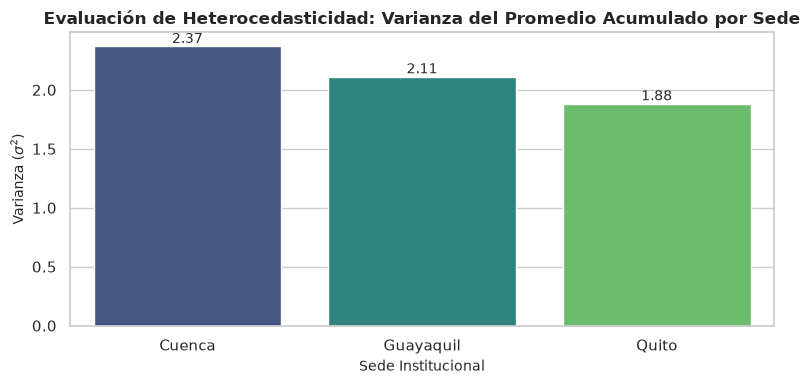

In [51]:
# =====================================================================
# 5. Visualización Gráfica de la Heterocedasticidad por Sedes
# =====================================================================
plt.figure(figsize=(8, 4))
ax = sns.barplot(x=varianzas_por_sede.index, y=varianzas_por_sede.values, hue=varianzas_por_sede.index, palette='viridis', legend=False)
plt.title(r'Evaluación de Heterocedasticidad: Varianza del Promedio Acumulado por Sede', fontsize=12, fontweight='bold')
plt.xlabel(r'Sede Institucional', fontsize=10)
plt.ylabel(r'Varianza ($\sigma^2$)', fontsize=10)

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

### ✅ Conclusión del Ítem 5.3

| Variabel | Resultado |
|---|---|
| **Heterocedasticidad por Sedes** | El análisis visual y numérico de las varianzas por sede demuestra que la dispersión del promedio acumulado no es constante entre los diferentes sedes. Al no cumplirse el supuesto de homocedasticidad (varianzas iguales en todos los subgrupos), se confirma formalmente que el comportamiento académico y la dispersión de notas varían significativamente dependiendo de la ubicación geográfica o sede del estudiante. <br> **Sesgo Geográfico:** Si un modelo de aprendizaje automático se entrena directamente con estos datos sin corrección previa, el algoritmo aprenderá patrones sesgados por la sede con mayor o menor variabilidad, restando equidad a las predicciones individuales. <br> **Mitigación:** Para garantizar un sistema de alerta temprana justo y neutral, la presencia de heterocedasticidad obliga técnicamente a implementar validación cruzada estratificada o a incorporar la "sede" como una variable categórica codificada, o bien aplicar normalización por grupos, asegurando que el modelo evalúe al estudiante dentro de su contexto institucional real.|

---

---

# 🔷 ÍTEM 6: Recomendación Ejecutiva

**Enunciado:**  
> Redacte una conclusión técnica y ética breve justificando si la universidad debe proceder con el modelado predictivo o completar primero la fase de diagnóstico de datos.

--- 

---

## ✅ Conclusión del Ítem 6


# DECISIÓN INSTITUCIONAL:

La universidad debe completar y robustecer la fase de diagnóstico de datos antes de proceder con el modelado predictivo definitivo.

## 6.1 Justificación Técnica

Los números hablan por sí solos: el Tiempo de Conexión tiene una dispersión gigante ($\approx 12,802.82$) si lo comparamos con el Promedio Acumulado. Si procedemos con estos datos tal cual a un algoritmo de Inteligencia Artificial, la máquina se va a confundir y le dará más importancia al tiempo de conexión solo porque los números son más grandes. Además, descubrimos que los estudiantes de diferentes sedes se comportan de forma distinta (heterocedasticidad). Entrenar un modelo directamente con estos desniveles provocaría que el sistema falle o aprenda erroneamente.

## 6.2 Justificación Ética

Desde el punto de vista de la ética en la IA, no podemos crear un sistema de alerta temprana que trate a todos los estudiantes con la misma regla si las realidades de cada campus son tan diferentes. Hacerlo podría generar un sesgo injusto y perjudicar por error a alumnos de sedes específicas. Por lo tanto, es una obligación ética y técnica aplicar primero herramientas de limpieza (como estandarizar los datos y ajustar las diferencias por sedes) para asegurarnos de que el futuro modelo sea justo, transparente y funcione bien para todos por igual.